# Архитектура данных: Data Warehouse, Data Lake, Lakehouse, Data Mesh

В этой лекции разбираем, как устроено хранение и обработка данных в реальных компаниях:
зачем появились хранилища данных (DWH), почему им на смену пришли озёра данных (Data Lake),
что такое Lakehouse и почему многие крупные компании сейчас переходят на децентрализованный
подход — Data Mesh.

**План лекции:**

1. Зачем вообще нужна архитектура данных
2. OLTP vs OLAP
3. Data Warehouse (DWH): звёздная схема, ETL
4. Data Lake: схема-при-чтении, форматы файлов, Bronze/Silver/Gold
5. Data Lakehouse: лучшее от DWH и Data Lake
6. Data Mesh: данные как продукт
7. Сравнение подходов
8. Инструменты в реальном мире
9. Как выбрать архитектуру
10. Важные выводы
11. Задания для практики

## 1. Зачем нужна архитектура данных

Любая компания начинает с одной базы данных — например, PostgreSQL, в которой живёт сайт
или приложение. Туда пишутся заказы, пользователи, платежи. Это **операционная** база данных,
её задача — быстро обслуживать транзакции (создать заказ, обновить профиль).

Проблема начинается, когда бизнесу нужна аналитика: "сколько мы заработали по регионам за
квартал", "как меняется удержание пользователей", "какие товары стоит закупить". Если слать
такие тяжёлые аналитические запросы прямо в продовую базу — она начнёт тормозить и мешать
работе самого приложения. К тому же данные для аналитики часто нужно собирать из **нескольких**
источников: базы данных, логи, CRM, рекламные кабинеты, файлы от партнёров.

Так возникает потребность в отдельной системе для хранения и анализа данных. Со временем
подходы к её построению эволюционировали:

| Период | Подход | Ключевая идея |
|---|---|---|
| 1990-е | **Data Warehouse (DWH)** | Структурированное хранилище для отчётов и BI |
| 2010-е | **Data Lake** | Храним сырые данные любого формата дёшево, структуру накладываем при чтении |
| Конец 2010-х | **Lakehouse** | Берём дешевизну Data Lake + надёжность и структуру DWH |
| С 2019 | **Data Mesh** | Не технология, а организационный подход: домены сами владеют своими данными |

Дальше разберём каждый подход подробно, с кодом и мини-примерами.

## 2. OLTP vs OLAP

Прежде чем говорить о хранилищах, важно понять разницу между двумя типами нагрузок на базу данных.

| | OLTP (Online Transaction Processing) | OLAP (Online Analytical Processing) |
|---|---|---|
| Назначение | Операционная работа приложения | Аналитика и отчётность |
| Типичный запрос | `INSERT`/`UPDATE` одной строки | `SELECT` с `GROUP BY` по миллионам строк |
| Ориентация хранения | Построчная (row-oriented) | Колоночная (column-oriented) |
| Нагрузка | Много коротких транзакций | Мало, но тяжёлых запросов |
| Примеры систем | PostgreSQL, MySQL | ClickHouse, BigQuery, Snowflake, Redshift |
| Пример вопроса | "Создать заказ №4521" | "Средний чек по всем заказам за 2025 год" |

👉 DWH и Data Lake/Lakehouse проектируются под **OLAP**-нагрузку: они оптимизированы под
чтение и агрегацию больших объёмов данных, а не под точечные быстрые транзакции.

Посмотрим на разницу на игрушечном примере с SQLite.

In [1]:
import sqlite3
import time
import random

conn = sqlite3.connect(":memory:")
cur = conn.cursor()
cur.execute('''
CREATE TABLE orders (
    id INTEGER PRIMARY KEY,
    customer_id INTEGER,
    category TEXT,
    amount REAL
)
''')

categories = ["electronics", "books", "clothes", "food", "toys"]

# --- OLTP-подобная нагрузка: много мелких вставок (одна "транзакция" = один заказ)
start = time.perf_counter()
for i in range(20_000):
    cur.execute(
        "INSERT INTO orders (customer_id, category, amount) VALUES (?, ?, ?)",
        (random.randint(1, 3000), random.choice(categories), round(random.uniform(5, 500), 2)),
    )
conn.commit()
oltp_time = time.perf_counter() - start
print(f"OLTP-вставка 20 000 строк по одной: {oltp_time:.3f} сек")

# --- OLAP-подобная нагрузка: одна тяжёлая агрегация по всей таблице
start = time.perf_counter()
cur.execute('''
    SELECT category, COUNT(*) AS orders_cnt, ROUND(SUM(amount), 2) AS revenue
    FROM orders
    GROUP BY category
    ORDER BY revenue DESC
''')
result = cur.fetchall()
olap_time = time.perf_counter() - start
print(f"OLAP-агрегация по 20 000 строк: {olap_time:.4f} сек\n")

for row in result:
    print(row)

OLTP-вставка 20 000 строк по одной: 0.043 сек
OLAP-агрегация по 20 000 строк: 0.0057 сек

('electronics', 4075, 1042531.64)
('food', 4051, 1020017.07)
('clothes', 3982, 998893.91)
('books', 3942, 989223.91)
('toys', 3950, 983666.25)


Даже на таком игрушечном примере видно: вставка по одной строке — это много маленьких
дешёвых операций, а аналитический запрос — это одна операция, которая просматривает
и агрегирует весь массив данных. На реальных объёмах (миллиарды строк) для второго типа
нагрузки строковое хранение становится узким местом — отсюда и колоночные СУБД для аналитики.

## 3. Data Warehouse (DWH)

**Data Warehouse** — это централизованное хранилище **структурированных** данных, заранее
приведённых к единой схеме, оптимизированное под аналитические запросы (OLAP).

Ключевая идея — **ETL (Extract, Transform, Load)**:

1. **Extract** — забираем данные из источников (продовая БД, CRM, логи, API)
2. **Transform** — чистим, приводим типы, агрегируем, соединяем справочники — **до** загрузки
3. **Load** — загружаем уже готовые, структурированные данные в DWH

Это значит, что схема данных проектируется **заранее** (schema-on-write) — прежде чем данные
попадут в хранилище, мы уже знаем, как именно они будут структурированы.

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def draw_box(ax, x, y, w, h, text, facecolor="#dbe9ff", edgecolor="#2b6cb0", fontsize=10, fontweight="normal"):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.6, edgecolor=edgecolor, facecolor=facecolor
    )
    ax.add_patch(box)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
             fontsize=fontsize, fontweight=fontweight, wrap=True)

def draw_arrow(ax, start, end, color="#4a5568", style="-|>"):
    arrow = FancyArrowPatch(
        start, end, arrowstyle=style, mutation_scale=16,
        linewidth=1.6, color=color
    )
    ax.add_patch(arrow)

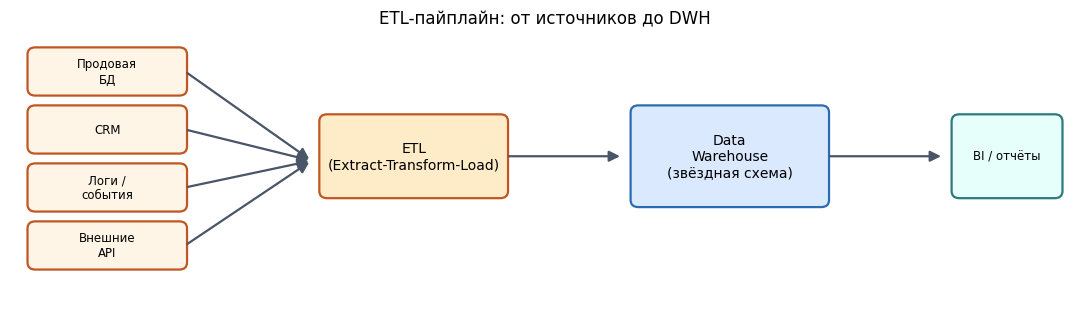

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3)
ax.axis("off")

sources = ["Продовая\nБД", "CRM", "Логи /\nсобытия", "Внешние\nAPI"]
for i, s in enumerate(sources):
    draw_box(ax, 0.2, 2.3 - i * 0.65, 1.6, 0.5, s, facecolor="#fff5e6", edgecolor="#c05621", fontsize=8.5)
    draw_arrow(ax, (1.8, 2.55 - i * 0.65), (3.1, 1.55))

draw_box(ax, 3.2, 1.15, 1.9, 0.9, "ETL\n(Extract-Transform-Load)", facecolor="#feebc8", edgecolor="#c05621")
draw_arrow(ax, (5.1, 1.6), (6.3, 1.6))

draw_box(ax, 6.4, 1.05, 2.0, 1.1, "Data\nWarehouse\n(звёздная схема)", facecolor="#dbe9ff", edgecolor="#2b6cb0")
draw_arrow(ax, (8.4, 1.6), (9.6, 1.6))

draw_box(ax, 9.7, 1.15, 1.1, 0.9, "BI / отчёты", facecolor="#e6fffa", edgecolor="#2c7a7b", fontsize=8.5)

ax.set_title("ETL-пайплайн: от источников до DWH", fontsize=12)
plt.tight_layout()
plt.show()

### Звёздная схема (Star Schema)

Внутри DWH данные чаще всего организуют по подходу **Kimball** — в виде **звёздной схемы**:
в центре — **таблица фактов** (fact table) с измеримыми событиями (продажи, клики, платежи),
а вокруг — **таблицы измерений** (dimension tables) с описательными атрибутами (кто, что, когда, где).

* **Fact table** — узкая и длинная: в основном числа (revenue, quantity) и внешние ключи на измерения
* **Dimension tables** — широкие и не очень длинные: текстовые атрибуты для фильтрации и группировки

Такая схема сильно ускоряет типичные аналитические запросы вида "сумма продаж по категории
и месяцу", потому что не нужно каждый раз пересчитывать агрегаты на лету по нормализованным таблицам.

Есть и альтернативный подход — **Inmon**: сначала строится полностью нормализованная (3NF)
модель хранилища верхнего уровня, а звёздные схемы под конкретные отделы (data marts) уже
строятся поверх неё. Inmon даёт меньше дублирования данных, Kimball — быстрее внедрить и проще
для аналитиков.

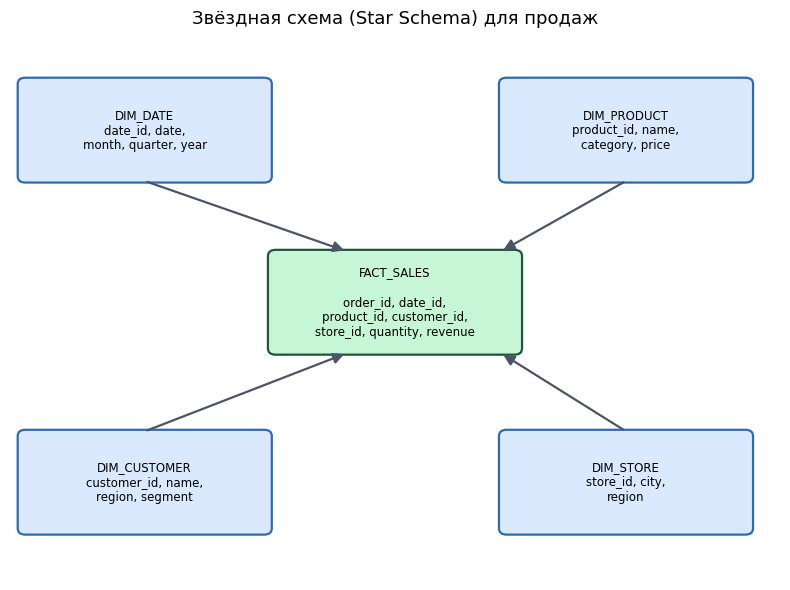

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 8)
ax.set_ylim(0, 7)
ax.axis("off")

draw_box(ax, 2.7, 2.9, 2.6, 1.3, "FACT_SALES\n\norder_id, date_id,\nproduct_id, customer_id,\nstore_id, quantity, revenue",
         facecolor="#c6f6d5", edgecolor="#22543d", fontsize=8.5)

dims = [
    ("DIM_DATE\ndate_id, date,\nmonth, quarter, year", (0.1, 5.1)),
    ("DIM_PRODUCT\nproduct_id, name,\ncategory, price", (5.1, 5.1)),
    ("DIM_CUSTOMER\ncustomer_id, name,\nregion, segment", (0.1, 0.6)),
    ("DIM_STORE\nstore_id, city,\nregion", (5.1, 0.6)),
]
for text, (x, y) in dims:
    draw_box(ax, x, y, 2.6, 1.3, text, facecolor="#dbe9ff", edgecolor="#2b6cb0", fontsize=8.5)

# связи (стрелки от измерений к факту)
draw_arrow(ax, (1.4, 5.1), (3.5, 4.2))
draw_arrow(ax, (6.4, 5.1), (5.1, 4.2))
draw_arrow(ax, (1.4, 1.9), (3.5, 2.9))
draw_arrow(ax, (6.4, 1.9), (5.1, 2.9))

ax.set_title("Звёздная схема (Star Schema) для продаж", fontsize=13)
plt.tight_layout()
plt.show()

### Практика: собираем звёздную схему и делаем OLAP-запрос

Сгенерируем синтетические данные о продажах и загрузим их в SQLite в виде звёздной схемы:
одна таблица фактов `fact_sales` и четыре таблицы измерений.

In [5]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

# --- Измерения ---------------------------------------------------------
dim_date = pd.DataFrame({
    "date_id": range(1, 366),
    "date": pd.date_range("2025-01-01", periods=365, freq="D"),
})
dim_date["month"] = dim_date["date"].dt.month
dim_date["quarter"] = dim_date["date"].dt.quarter

categories = ["electronics", "books", "clothes", "food", "toys"]
dim_product = pd.DataFrame({
    "product_id": range(1, 31),
    "name": [f"product_{i}" for i in range(1, 31)],
    "category": rng.choice(categories, size=30),
    "price": rng.uniform(5, 500, size=30).round(2),
})

regions = ["North", "South", "East", "West"]
dim_customer = pd.DataFrame({
    "customer_id": range(1, 201),
    "region": rng.choice(regions, size=200),
    "segment": rng.choice(["retail", "wholesale"], size=200, p=[0.8, 0.2]),
})

dim_store = pd.DataFrame({
    "store_id": range(1, 6),
    "city": ["Moscow", "SPB", "Kazan", "Novosibirsk", "Sochi"],
})

# --- Таблица фактов ------------------------------------------------------
n = 8000
fact_sales = pd.DataFrame({
    "order_id": range(1, n + 1),
    "date_id": rng.integers(1, 366, size=n),
    "product_id": rng.integers(1, 31, size=n),
    "customer_id": rng.integers(1, 201, size=n),
    "store_id": rng.integers(1, 6, size=n),
    "quantity": rng.integers(1, 6, size=n),
})
fact_sales = fact_sales.merge(dim_product[["product_id", "price"]], on="product_id")
fact_sales["revenue"] = (fact_sales["quantity"] * fact_sales["price"]).round(2)
fact_sales = fact_sales.drop(columns="price")

print(fact_sales.head())
print(f"\nВсего строк в fact_sales: {len(fact_sales)}")

   order_id  date_id  product_id  customer_id  store_id  quantity  revenue
0         1      364          11           43         3         2   202.70
1         2      291          29          103         3         1   159.62
2         3      340          30           62         5         2   833.94
3         4      346          23          126         1         3   721.41
4         5       33          14          149         3         2   162.74

Всего строк в fact_sales: 8000


In [6]:
dwh = sqlite3.connect(":memory:")
dim_date.to_sql("dim_date", dwh, index=False)
dim_product.to_sql("dim_product", dwh, index=False)
dim_customer.to_sql("dim_customer", dwh, index=False)
dim_store.to_sql("dim_store", dwh, index=False)
fact_sales.to_sql("fact_sales", dwh, index=False)

query = '''
SELECT
    dp.category,
    dd.quarter,
    ROUND(SUM(fs.revenue), 2) AS revenue,
    COUNT(*) AS orders_cnt
FROM fact_sales fs
JOIN dim_product dp ON fs.product_id = dp.product_id
JOIN dim_date dd ON fs.date_id = dd.date_id
GROUP BY dp.category, dd.quarter
ORDER BY dp.category, dd.quarter
'''
report = pd.read_sql(query, dwh)
report.head(10)

,category,quarter,revenue,orders_cnt
0,books,1,96466.26,127
1,books,2,114148.78,135
2,books,3,123253.58,150
3,books,4,117611.26,144
4,clothes,1,524931.53,606
5,clothes,2,563724.93,645
6,clothes,3,515359.38,581
7,clothes,4,494495.58,594
8,electronics,1,237344.67,345
9,electronics,2,245218.36,365


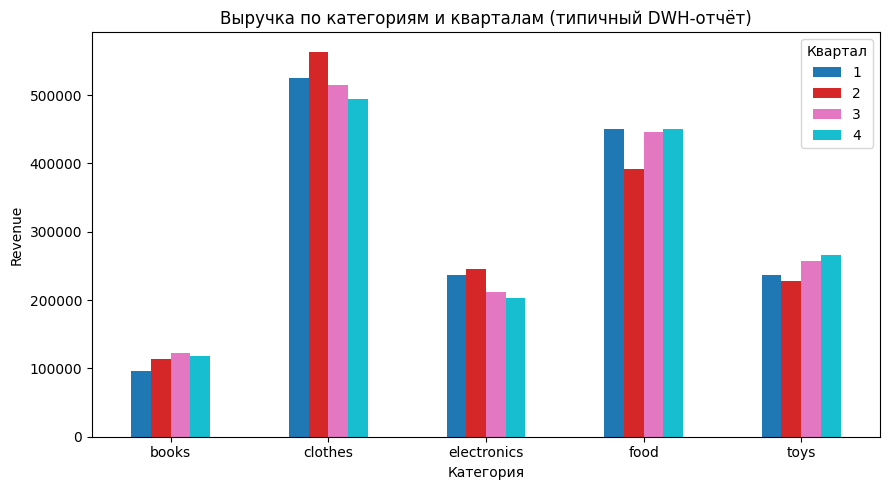

In [7]:
pivot = report.pivot(index="category", columns="quarter", values="revenue")
pivot.plot(kind="bar", figsize=(9, 5), colormap="tab10")
plt.title("Выручка по категориям и кварталам (типичный DWH-отчёт)")
plt.ylabel("Revenue")
plt.xlabel("Категория")
plt.xticks(rotation=0)
plt.legend(title="Квартал")
plt.tight_layout()
plt.show()

Это типичный сценарий использования DWH: данные уже приведены к чистой звёздной схеме,
поэтому аналитический `JOIN + GROUP BY` выполняется быстро и предсказуемо, а результат
сразу готов для BI-дашборда (Tableau, Power BI, Looker и т.п.).

**Минусы DWH:**

* Дорого хранить сырые/неструктурированные данные (видео, логи, JSON) — всё нужно заранее превращать в таблицы
* ETL жёсткий: если источник поменял формат, пайплайн ломается
* Плохо подходит для ML-инженеров, которым нужны сырые данные для обучения моделей

## 4. Data Lake

**Data Lake** — это хранилище, куда данные складываются **как есть**, в исходном формате:
CSV, JSON, логи, изображения, видео, Parquet — что угодно. Обычно это объектное хранилище
(Amazon S3, Azure Data Lake Storage, Google Cloud Storage, или self-hosted HDFS/MinIO).

Ключевое отличие от DWH — подход **ELT** и **schema-on-read**:

* **E**xtract — забираем данные из источника
* **L**oad — сразу грузим "как есть" в озеро, без предварительной трансформации
* **T**ransform — данные преобразуются **позже**, в момент чтения/анализа, а не до записи

Это даёт гибкость (можно хранить вообще всё, не думая заранее о схеме) и дешевизну
(объектное хранилище стоит на порядок дешевле, чем место в классической СУБД), но
без дисциплины легко превращается в **data swamp** ("болото данных") — гору файлов,
в которых никто не понимает, что где лежит и можно ли им доверять.

### Форматы файлов

| Формат | Тип | Особенности |
|---|---|---|
| CSV / JSON | построчный, текстовый | Просто читать глазами, но медленно и много весит |
| Avro | построчный, бинарный | Хорош для потоковой записи (Kafka) |
| **Parquet** | колоночный, бинарный | Индустриальный стандарт для аналитики: сжатие + чтение только нужных колонок |
| ORC | колоночный, бинарный | Похож на Parquet, чаще встречается в экосистеме Hive |

Сравним CSV и Parquet на практике.

In [8]:
import os

lake_dir = "data/lake_demo"
os.makedirs(lake_dir, exist_ok=True)

# Для честного сравнения скорости чтения возьмём датасет побольше — на маленьких файлах
# (тысячи строк) разница незаметна на фоне фиксированных накладных расходов движков.
big_sales = pd.concat([fact_sales] * 20, ignore_index=True)  # ~160 000 строк

csv_path = os.path.join(lake_dir, "fact_sales.csv")
parquet_path = os.path.join(lake_dir, "fact_sales.parquet")

big_sales.to_csv(csv_path, index=False)
big_sales.to_parquet(parquet_path, index=False)

csv_size = os.path.getsize(csv_path) / 1024
parquet_size = os.path.getsize(parquet_path) / 1024
print(f"Строк: {len(big_sales):,}")
print(f"CSV:     {csv_size:8.1f} КБ")
print(f"Parquet: {parquet_size:8.1f} КБ  (в {csv_size / parquet_size:.1f}x компактнее)")

# --- скорость чтения только одной колонки ---
# "прогреваем" parquet-движок одним холостым чтением, чтобы не мерить время его инициализации
_ = pd.read_parquet(parquet_path, columns=["revenue"])

start = time.perf_counter()
_ = pd.read_csv(csv_path, usecols=["revenue"])
csv_time = time.perf_counter() - start

start = time.perf_counter()
_ = pd.read_parquet(parquet_path, columns=["revenue"])
parquet_time = time.perf_counter() - start

print(f"\nЧтение одной колонки 'revenue':")
print(f"CSV:     {csv_time * 1000:6.2f} мс")
print(f"Parquet: {parquet_time * 1000:6.2f} мс  (в {csv_time / parquet_time:.1f}x быстрее)")

Строк: 160,000
CSV:       4185.5 КБ
Parquet:    819.5 КБ  (в 5.1x компактнее)

Чтение одной колонки 'revenue':
CSV:      45.11 мс
Parquet:   3.11 мс  (в 14.5x быстрее)


Parquet — колоночный формат: чтобы прочитать одну колонку, не нужно построчно парсить
весь файл целиком, как в CSV. На больших датасетах (десятки-сотни ГБ) разница становится
критичной, поэтому Parquet — стандарт де-факто для Data Lake / Lakehouse.

### Медальонная архитектура (Bronze / Silver / Gold)

Чтобы Data Lake не превращался в свалку, применяют слоистую организацию —
**medallion architecture**:

* 🥉 **Bronze** — сырые данные "как есть" из источника, без изменений (даже с ошибками/дублями)
* 🥈 **Silver** — очищенные и приведённые к единому виду данные (типы, дедупликация, валидация)
* 🥇 **Gold** — агрегированные, готовые для бизнес-анализа витрины данных

Смоделируем такой пайплайн на игрушечном примере с "грязными" данными.

C:\Users\raven\AppData\Local\Temp\ipykernel_8112\1028706051.py:17: UserWarning: Glyph 129353 (\N{THIRD PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\raven\AppData\Local\Temp\ipykernel_8112\1028706051.py:17: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\raven\AppData\Local\Temp\ipykernel_8112\1028706051.py:17: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\raven\Projects\tutor\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129353 (\N{THIRD PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\raven\Projects\tutor\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\raven\Projects\tutor\venv\Lib\site-packages\IPython

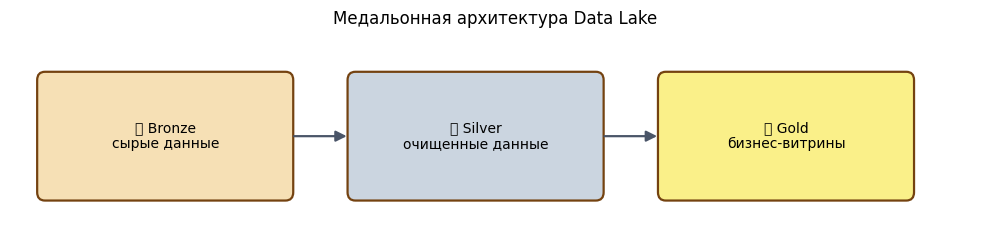

In [9]:
fig, ax = plt.subplots(figsize=(10, 2.6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2)
ax.axis("off")

stages = [
    ("🥉 Bronze\nсырые данные", "#f6e0b5"),
    ("🥈 Silver\nочищенные данные", "#cbd5e0"),
    ("🥇 Gold\nбизнес-витрины", "#faf089"),
]
for i, (text, color) in enumerate(stages):
    draw_box(ax, 0.3 + i * 3.2, 0.4, 2.6, 1.2, text, facecolor=color, edgecolor="#744210", fontsize=10)
    if i < 2:
        draw_arrow(ax, (2.9 + i * 3.2, 1.0), (3.5 + i * 3.2, 1.0))

ax.set_title("Медальонная архитектура Data Lake", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# --- Bronze: сырые "грязные" данные, как будто выгрузили из лога веб-сайта ---
raw_events = pd.DataFrame({
    "event_id": [1, 2, 3, 4, 4, 5, 6],  # дубль id=4
    "category": ["Electronics", "books", "CLOTHES", "food", "food", None, "toys"],
    "amount": ["120.5", "15", "-", "45.0", "45.0", "30", "12.99"],
    "event_date": ["2025-03-01", "2025-03-01", "2025-03-02", "2025-03-02", "2025-03-02", "2025-03-03", "bad_date"],
})

bronze_path = os.path.join(lake_dir, "bronze_events.parquet")
raw_events.to_parquet(bronze_path, index=False)
print("Bronze (сырые данные):")
raw_events

Bronze (сырые данные):


,event_id,category,amount,event_date
0,1,Electronics,120.5,2025-03-01
1,2,books,15,2025-03-01
2,3,CLOTHES,-,2025-03-02
3,4,food,45.0,2025-03-02
4,4,food,45.0,2025-03-02
5,5,None,30,2025-03-03
6,6,toys,12.99,bad_date


In [11]:
# --- Silver: чистим, приводим типы, убираем дубли и явно некорректные строки ---
silver = raw_events.copy()
silver["category"] = silver["category"].str.lower()
silver["amount"] = pd.to_numeric(silver["amount"], errors="coerce")
silver["event_date"] = pd.to_datetime(silver["event_date"], errors="coerce")

silver = silver.drop_duplicates(subset="event_id")
silver = silver.dropna(subset=["category", "amount", "event_date"])
silver = silver[silver["amount"] > 0]

silver_path = os.path.join(lake_dir, "silver_events.parquet")
silver.to_parquet(silver_path, index=False)
print("Silver (очищенные данные):")
silver

Silver (очищенные данные):


,event_id,category,amount,event_date
0,1,electronics,120.5,2025-03-01
1,2,books,15.0,2025-03-01
3,4,food,45.0,2025-03-02


In [12]:
# --- Gold: агрегированная витрина для аналитиков/BI ---
gold = (
    silver.groupby("category", as_index=False)
    .agg(total_amount=("amount", "sum"), events_cnt=("event_id", "count"))
    .sort_values("total_amount", ascending=False)
)

gold_path = os.path.join(lake_dir, "gold_category_summary.parquet")
gold.to_parquet(gold_path, index=False)
print("Gold (бизнес-витрина):")
gold

Gold (бизнес-витрина):


,category,total_amount,events_cnt
1,electronics,120.5,1
2,food,45.0,1
0,books,15.0,1


Из 7 сырых записей после Bronze → Silver → Gold остались только валидные, дедуплицированные
и агрегированные данные. Каждый слой физически лежит отдельно (в реальных системах — отдельные
папки/бакеты в S3), поэтому всегда можно вернуться к сырым данным и пересчитать всё заново,
если в логике очистки нашлась ошибка.

## 5. Data Lakehouse

Data Lake дешёвый и гибкий, но у него нет того, что исторически было сильной стороной DWH:

* **ACID-транзакций** (что если два процесса одновременно пишут в одну таблицу?)
* **Enforced-схемы** (что если кто-то случайно записал файл с другими типами колонок?)
* **Time travel** — возможности посмотреть, как выглядела таблица вчера/неделю назад
* Быстрых `UPDATE`/`DELETE` по отдельным строкам (объектное хранилище "из коробки" такого не умеет)

**Lakehouse** — это архитектура, которая добавляет такой уровень поверх обычного объектного
хранилища. Технически это реализуется через дополнительный "transaction log" / "manifest"
рядом с файлами данных. Самые известные реализации:

* **Delta Lake** (Databricks) — свой формат лога транзакций поверх Parquet
* **Apache Iceberg** (изначально Netflix) — открытый табличный формат, сейчас стандарт индустрии
* **Apache Hudi** (Uber) — похожий подход, силён в инкрементальных обновлениях

Идея всех трёх одна: рядом с файлами `.parquet` лежит **лог версий (manifest)**, который
говорит "актуальная версия таблицы — это вот эти файлы". Смоделируем эту идею на упрощённом
примере — без реальной Iceberg/Delta, просто чтобы понять механику **time travel**.

In [ ]:
import json
import shutil
from datetime import datetime

lakehouse_dir = os.path.join(lake_dir, "lakehouse_gold")
shutil.rmtree(lakehouse_dir, ignore_errors=True)  # чистый старт при каждом запуске ноутбука
os.makedirs(lakehouse_dir, exist_ok=True)
manifest_path = os.path.join(lakehouse_dir, "_manifest.json")


def write_table_version(df: pd.DataFrame, table_dir: str, manifest_path: str) -> int:
    '''Записывает новую версию таблицы и обновляет manifest (упрощённая имитация Delta/Iceberg).'''
    if os.path.exists(manifest_path):
        with open(manifest_path, encoding="utf-8") as f:
            manifest = json.load(f)
    else:
        manifest = {"versions": []}

    version = len(manifest["versions"])
    file_name = f"version_{version}.parquet"
    df.to_parquet(os.path.join(table_dir, file_name), index=False)

    manifest["versions"].append({
        "version": version,
        "file": file_name,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "rows": len(df),
    })
    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)
    return version


def read_table_version(table_dir: str, manifest_path: str, version: int | None = None) -> pd.DataFrame:
    '''Читает таблицу по номеру версии; version=None -> последняя версия (time travel).'''
    with open(manifest_path, encoding="utf-8") as f:
        manifest = json.load(f)
    entry = manifest["versions"][-1] if version is None else manifest["versions"][version]
    return pd.read_parquet(os.path.join(table_dir, entry["file"]))


# версия 0: исходная gold-витрина
v0 = write_table_version(gold, lakehouse_dir, manifest_path)

# версия 1: бизнес попросил исправить сумму по категории "food" (нашли ошибку в источнике)
gold_v1 = gold.copy()
gold_v1.loc[gold_v1["category"] == "food", "total_amount"] += 100
v1 = write_table_version(gold_v1, lakehouse_dir, manifest_path)

print("Актуальная версия таблицы:")
print(read_table_version(lakehouse_dir, manifest_path))

print("\nTime travel — версия 0 (как было ДО исправления):")
print(read_table_version(lakehouse_dir, manifest_path, version=0))

Актуальная версия таблицы:
      category  total_amount  events_cnt
0  electronics         120.5           1
1         food         145.0           1
2        books          15.0           1

Time travel — версия 0 (как было ДО исправления):
      category  total_amount  events_cnt
0  electronics         120.5           1
1         food          45.0           1
2        books          15.0           1


Это, конечно, сильно упрощённая модель, но именно на этом принципе — **неизменяемые файлы
данных + отдельный лог версий поверх них** — построены и Delta Lake, и Iceberg, и Hudi.
Благодаря этому Lakehouse даёт ACID-гарантии и time travel прямо поверх дешёвого объектного
хранилища, оставаясь при этом таким же гибким, как обычный Data Lake (можно хранить любые
форматы, поверх тех же файлов можно запускать и SQL-движки, и ML-пайплайны).

## 6. Data Mesh

DWH, Data Lake и Lakehouse — это **технологии**. **Data Mesh** — это, в первую очередь,
**организационный** подход, предложенный Zhamak Dehghani (Thoughtworks) в 2019 году.

Проблема, которую решает Data Mesh: в крупных компаниях с десятками команд один центральный
data-инженерный отдел физически не успевает поддерживать пайплайны для всех остальных команд.
Он становится "бутылочным горлышком": любое изменение в данных требует создания тикета
в очередь центральной команды.

Data Mesh предлагает 4 принципа:

1. **Domain-oriented ownership** — данными владеет та команда (домен), которая их производит
   (например, команда Logistics владеет данными о доставках), а не центральный data-отдел
2. **Data as a product** — каждый домен публикует свои данные как продукт: с понятной схемой,
   SLA, документацией, метриками качества — как будто это внешний API
3. **Self-serve data platform** — общая инфраструктурная платформа (хранилище, каталог,
   мониторинг), которой домены пользуются самостоятельно, без похода к центральной команде
4. **Federated computational governance** — общие для всех стандарты (форматы, security,
   naming conventions), но не централизованный контроль каждого пайплайна

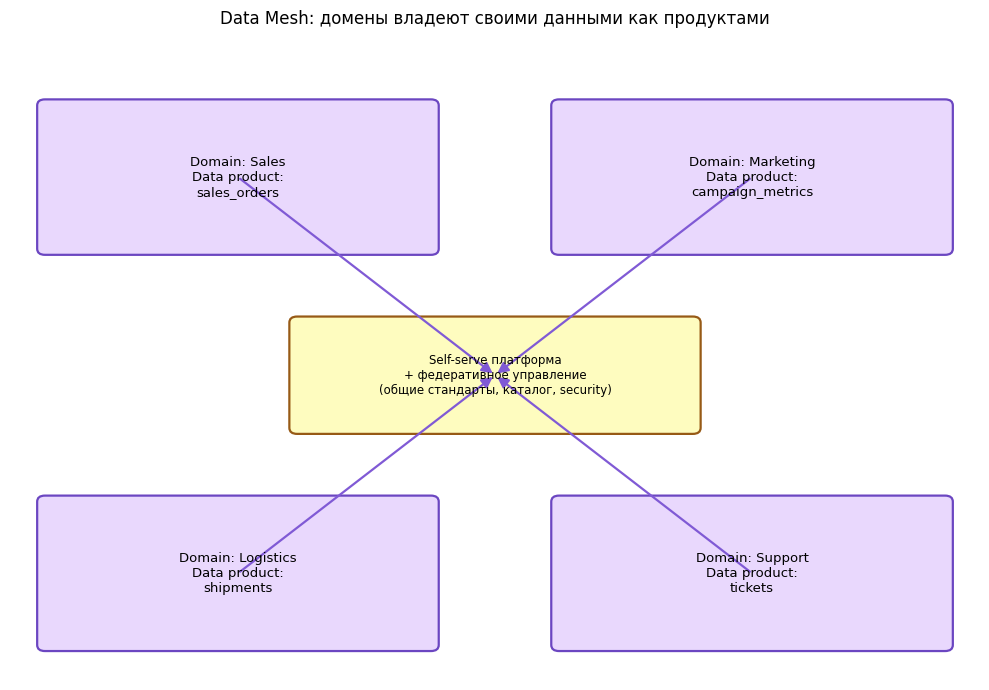

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8.5)
ax.axis("off")

domains = [
    ("Domain: Sales\nData product:\nsales_orders", (0.3, 5.6)),
    ("Domain: Marketing\nData product:\ncampaign_metrics", (5.6, 5.6)),
    ("Domain: Logistics\nData product:\nshipments", (0.3, 0.4)),
    ("Domain: Support\nData product:\ntickets", (5.6, 0.4)),
]
for text, (x, y) in domains:
    draw_box(ax, x, y, 4.1, 2.0, text, facecolor="#e9d8fd", edgecolor="#6b46c1", fontsize=9.5)

draw_box(ax, 2.9, 3.25, 4.2, 1.5,
         "Self-serve платформа\n+ федеративное управление\n(общие стандарты, каталог, security)",
         facecolor="#fefcbf", edgecolor="#975a16", fontsize=8.5)

for text, (x, y) in domains:
    cx, cy = x + 2.05, y + 1.0
    px, py = 5.0, 4.0
    draw_arrow(ax, (cx, cy), (px, py), color="#805ad5")

ax.set_title("Data Mesh: домены владеют своими данными как продуктами", fontsize=12)
plt.tight_layout()
plt.show()

### Данные как продукт: контракт и валидация

Ключевая практика Data Mesh — у каждого "продукта данных" есть явный **контракт**: схема,
владелец, SLA, правила качества. Потребители данных полагаются на контракт, а не на
"договорились на словах". Смоделируем такой контракт для нашей gold-витрины продаж
и напишем простую проверку соответствия.

In [15]:
from dataclasses import dataclass, field


@dataclass
class DataProductContract:
    domain: str
    name: str
    owner: str
    schema: dict            # {column_name: expected_dtype_kind}
    sla_freshness_hours: int
    max_null_share: float = 0.0


sales_contract = DataProductContract(
    domain="Sales",
    name="gold_category_summary",
    owner="sales-data-team@company.com",
    schema={"category": "object", "total_amount": "float", "events_cnt": "int"},
    sla_freshness_hours=24,
    max_null_share=0.01,
)


def validate_data_product(df: pd.DataFrame, contract: DataProductContract) -> list[str]:
    '''Возвращает список нарушений контракта (пустой список = всё ок).'''
    issues = []

    missing_cols = set(contract.schema) - set(df.columns)
    if missing_cols:
        issues.append(f"Отсутствуют колонки: {missing_cols}")

    for col, expected_kind in contract.schema.items():
        if col not in df.columns:
            continue
        actual_kind = df[col].dtype.kind
        kind_map = {"object": "O", "float": "f", "int": "i"}
        if actual_kind != kind_map.get(expected_kind, expected_kind):
            issues.append(f"Колонка '{col}': ожидался тип '{expected_kind}', получен kind='{actual_kind}'")

    for col in contract.schema:
        if col in df.columns:
            null_share = df[col].isna().mean()
            if null_share > contract.max_null_share:
                issues.append(f"Колонка '{col}': доля пропусков {null_share:.1%} > лимита {contract.max_null_share:.1%}")

    return issues


issues = validate_data_product(gold_v1, sales_contract)
if not issues:
    print(f"✅ Data product '{sales_contract.name}' прошёл проверку контракта, владелец: {sales_contract.owner}")
else:
    print(f"❌ Найдены нарушения контракта для '{sales_contract.name}':")
    for issue in issues:
        print(" -", issue)

✅ Data product 'gold_category_summary' прошёл проверку контракта, владелец: sales-data-team@company.com


В реальных Data Mesh-платформах эту роль играют такие инструменты, как **dbt contracts**,
**Great Expectations**, **Soda**, каталоги данных (**DataHub**, **Amundsen**) — но идея та же:
явный, проверяемый машиной контракт вместо неформальной договорённости между командами.

**Важно:** Data Mesh — это не "нужно всем компаниям". Это оправданно, когда компания уже
достаточно большая, у неё много независимых доменов, и центральная data-команда реально стала
узким местом. Для стартапа с одной командой аналитиков Data Mesh почти всегда избыточен.

## 7. Сравнение подходов

| | Data Warehouse | Data Lake | Lakehouse | Data Mesh |
|---|---|---|---|---|
| Тип данных | Структурированные | Любые (raw) | Любые + структура | Любые, по доменам |
| Схема | schema-on-write | schema-on-read | schema-on-write и read | зависит от домена |
| Стоимость хранения | Высокая | Низкая | Низкая | Зависит от платформы |
| ACID-транзакции | ✅ Да | ❌ Нет | ✅ Да | Зависит от платформы |
| Гибкость под ML/Data Science | ❌ Низкая | ✅ Высокая | ✅ Высокая | ✅ Высокая |
| Владение данными | Центральная команда | Центральная команда | Центральная команда | Домены (децентрализовано) |
| Типичный пользователь | BI-аналитик | Data Scientist / инженер | И тот, и другой | Все, через продукт домена |
| Это про технологию или про организацию? | Технология | Технология | Технология | **Организационный подход** |

Важно понимать: **Data Mesh — не альтернатива DWH/Lake/Lakehouse**, а надстройка над ними.
Каждый домен внутри Data Mesh вполне может использовать Lakehouse или DWH как свою внутреннюю
технологию — просто отвечает за неё сам, а не центральная команда.

## 8. Инструменты в реальном мире

| Категория | Примеры |
|---|---|
| Классический DWH (managed) | Snowflake, Google BigQuery, Amazon Redshift, ClickHouse |
| Объектное хранилище (Data Lake) | Amazon S3, Azure Data Lake Storage (ADLS), Google Cloud Storage |
| Табличные форматы Lakehouse | Delta Lake, Apache Iceberg, Apache Hudi |
| Движки обработки | Apache Spark, Trino/Presto, DuckDB, Databricks |
| Оркестрация пайплайнов | Apache Airflow, Dagster, Prefect |
| Трансформации (T в ELT) | dbt (data build tool) |
| Потоковая передача данных | Apache Kafka, AWS Kinesis |
| Каталог данных / governance | DataHub, Amundsen, Collibra |
| Контроль качества данных | Great Expectations, Soda, dbt tests |

На практике очень много компаний сегодня используют связку: **S3/ADLS (Data Lake) + Iceberg/Delta
(Lakehouse-слой) + Spark/Trino (обработка) + dbt (трансформации) + Airflow (оркестрация)** —
и уже поверх этого стека при необходимости выстраивают Data Mesh как организационную практику.

## 9. Как выбрать архитектуру

Коротких универсальных советов:

* **Только начинаете, данные небольшие, нужна аналитика/BI** → классический **DWH**
  (BigQuery/Snowflake — можно поднять за день, платить только за использование)
* **Нужно хранить сырые данные разных форматов, много ML/Data Science** → **Data Lake**
* **Нужны и ACID-гарантии, и дешевизна object storage, и ML, и BI на одних данных** → **Lakehouse**
  (сейчас это фактически дефолтный выбор для новых проектов среднего/крупного масштаба)
* **Компания большая, много независимых команд, центральная data-команда — бутылочное горлышко**
  → пора задуматься про организационные принципы **Data Mesh** поверх уже имеющейся технологии

Архитектуру не выбирают на всю жизнь: типичный путь роста компании — DWH → Data Lake/Lakehouse →
(при достаточном масштабе) добавление принципов Data Mesh поверх существующего стека.

## 10. Важные выводы

👉 **DWH**: структурированные данные, ETL, schema-on-write, звёздная схема, лучший выбор
для классической BI-аналитики.

👉 **Data Lake**: сырые данные любого формата, ELT, schema-on-read, дёшево и гибко, но
риск превратиться в "data swamp" без дисциплины (Bronze/Silver/Gold помогает её навести).

👉 **Lakehouse**: transaction log/manifest поверх файлов объектного хранилища даёт
ACID-транзакции и time travel, сохраняя гибкость и низкую стоимость Data Lake.

👉 **Data Mesh**: не технология, а организационный подход — домены владеют данными как
продуктами, с явным контрактом (схема, SLA, качество), а не центральная data-команда.

👉 На практике эти подходы **не взаимоисключающие**: Lakehouse — это уже почти стандарт
как технология, а Data Mesh — это то, как эту технологию распределяют по командам в
больших организациях.

## 11. Задания для практики

1. Добавьте в звёздную схему из раздела 3 ещё одно измерение `dim_promo` (акции/скидки)
   и напишите OLAP-запрос "выручка по категориям с учётом того, была ли акция".
2. Возьмите пайплайн Bronze → Silver → Gold из раздела 4 и добавьте в Bronze ещё один
   тип "грязных" данных (например, отрицательные суммы или будущие даты) — расширьте
   логику очистки в Silver так, чтобы такие строки отсеивались с логированием причины.
3. В функцию `write_table_version` из раздела 5 добавьте возможность "отката" —
   функцию `rollback(table_dir, manifest_path, to_version)`, которая делает текущей
   версией одну из предыдущих (по аналогии с `RESTORE TABLE ... TO VERSION` в Delta Lake).
4. Придумайте контракт данных (`DataProductContract`) для другого домена — например,
   "Logistics" с продуктом `shipments`, и напишите тестовые данные, которые его либо
   проходят, либо явно нарушают (для проверки, что `validate_data_product` действительно работает).